# SWOOSH and Ozone sonde O3 Comparison

SWOOSH comined ACE and MLS O3 data wre compared against NOAA GML ozone sonde data (from Boulder). 

To do this, ozone sonde EqLat data is generated from ERA5 and MERRA-2. 
This was done on thr HPC Orion, and combined data sets are in data/ozonesonde

In [596]:
import sys
import os
import gc
import re
import io
import time
import requests
from datetime import datetime
import pathlib
from pathlib import Path
from glob import glob
from datetime import timedelta

# Data Analysis & Science
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from bs4 import BeautifulSoup
import h5py 
from scipy import stats
from scipy.interpolate import RegularGridInterpolator

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

In [597]:
ozonesonde_dir = os.path.join(
    pathlib.Path.home(),
    'Documents',
    'GitHub',
    'eqlat_HPC',
    'data',
    'ozonesonde'
)

### Merge all single profiles into one large one

In [598]:
csv_files = sorted(glob(os.path.join(ozonesonde_dir, '*.csv')))

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['sonde_file'] = os.path.basename(f)
    dfs.append(df)

ozonesonde_df = pd.concat(dfs, ignore_index=True, sort=False)
ozonesonde_df['DATETIME GMT'] = pd.to_datetime(ozonesonde_df['DATETIME GMT'], errors='coerce')

print(f'{len(csv_files)} files -> {ozonesonde_df.shape[0]} rows, {ozonesonde_df.shape[1]} columns')
ozonesonde_df.columns

341 files -> 3098634 rows, 87 columns


Index(['Time [min]', 'Time Sec [sec]', 'Time GMT [hh:mm:ss GMT]',
       'Press [hPa]', 'Praw [hPa]', 'Alt [km]', 'Tcorr [deg C]',
       'Temp [deg C]', 'Traw [deg C]', 'Theta [K]', 'RH [%]', 'RHraw [%]',
       'TFp V [deg C]', 'RS H2O Mr [ppmv]', 'IPW V [mm]', 'TVaisI [deg C]',
       'RS Bat [V]', 'RS P Temp [deg C]', 'RS U Temp [deg C]',
       'Rise Rate [m/s]', 'O3 Cell I [uA]', 'O3 P [mPa]', 'O3 Mr [ppmv]',
       'T Pump [deg C]', 'T Pump Raw [deg C]', 'O3Bat [V]', 'I Pump [mA]',
       'Total Column O3 [DU]', 'Total w/ Extrap O3 [DU]',
       'Total w/ SBUV O3 [DU]', 'O3 Current Uncert [%]',
       'O3 Conversion Uncert [%]', 'O3 Flowrate Uncert [%]',
       'O3 Pump Temp Uncert [%]', 'O3 Total Uncert [%]', 'GPS lat [deg]',
       'GPS lon [deg]', 'GPS alt [km]', 'GPS sats []',
       'GPS Time [hh:mm:ss GMT]', 'GPS Press [mb]', 'GPS Heading [deg]',
       'GPS Elev Angle [deg]', 'Wind Speed [m/s]', 'Wind Dir [deg]',
       'DATETIME GMT', 'launch_lat', 'launch_lon', 'eqlat_E

In [599]:
def bin_o3_eqlat(df, eqlat_col, o3_col='O3 Mr [ppmv]', bin_col='theta_K',
                         eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 2000, 50),
                         log_bins=False, min_count=3):
    """Average Ozone sonde onto an equivalent-latitude x vertical-coordinate grid.

    Set log_bins=True for a log-spaced vertical coordinate (e.g. pressure,
    ordered increasing since pd.cut requires monotonically increasing bins),
    matching the SWOOSH pressure binning: bin centers then use the geometric
    mean instead of the arithmetic mean, and the output dim is named 'pressure'.

    Bins with fewer than min_count observations are left as NaN.
    """
    eqlat_centers = 0.5 * (eqlat_bins[:-1] + eqlat_bins[1:])
    theta_centers = (np.sqrt(bins[:-1] * bins[1:]) if log_bins
                      else 0.5 * (bins[:-1] + bins[1:]))

    valid = df[[eqlat_col, bin_col, o3_col]].dropna()

    eqlat_idx = pd.cut(valid[eqlat_col], eqlat_bins, labels=False)
    theta_idx = pd.cut(valid[bin_col], bins, labels=False)

    shape = (len(eqlat_centers), len(theta_centers))
    #binned = np.full((len(eqlat_centers), len(theta_centers)), np.nan)
    mean_binned = np.full(shape, np.nan)
    std_binned = np.full(shape, np.nan)
    count_binned = np.zeros(shape, dtype=int)
    grouped = valid.groupby([eqlat_idx, theta_idx], observed=True)[o3_col].agg(['mean', 'std', 'count'])

    for (i, j), row in grouped.iterrows():
        count_binned[int(i), int(j)] = row['count']
        if row['count'] >= min_count:
            mean_binned[int(i), int(j)] = row['mean']
            std_binned[int(i), int(j)] = row['std']

    vert_dim = 'pressure' if log_bins else 'theta'
    dims = ['eqlat', vert_dim]
    coords = {'eqlat': eqlat_centers, vert_dim: theta_centers}
    return xr.Dataset(
        {
            'mean': (dims, mean_binned),
            'std': (dims, std_binned),
            'count': (dims, count_binned),
        },
        coords=coords,
        attrs={'name': o3_col.strip()},
    )


SEASON_MAP = {12: 'DJF', 1: 'DJF', 2: 'DJF',
              3: 'MAM', 4: 'MAM', 5: 'MAM',
              6: 'JJA', 7: 'JJA', 8: 'JJA',
              9: 'SON', 10: 'SON', 11: 'SON'}


def bin_o3_eqlat_theta_seasonal(df, eqlat_col, o3_col='O3 Mr [ppmv]', bin_col='theta_K',
                                  time_col='DATETIME GMT',
                                  eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 1400, 50),
                                  log_bins=False):
    """Same as bin_o3_eqlat, but split into DJF/MAM/JJA/SON before binning.

    Set log_bins=True for a log-spaced vertical coordinate like pressure,
    same as bin_o3_eqlat.
    """
    season = pd.to_datetime(df[time_col]).dt.month.map(SEASON_MAP)

    binned_per_season = {
        s: bin_o3_eqlat(df[season == s], eqlat_col, o3_col, bin_col, eqlat_bins, bins, log_bins)
        for s in ['DJF', 'MAM', 'JJA', 'SON']
    }
    return xr.concat(binned_per_season.values(), dim=pd.Index(binned_per_season.keys(), name='season'))

In [600]:
o3_era5_eqlat_theta_seasonal = bin_o3_eqlat_theta_seasonal(ozonesonde_df, 'eqlat_ERA5_piecewise')
o3_merra2_eqlat_theta_seasonal = bin_o3_eqlat_theta_seasonal(ozonesonde_df, 'eqlat_MERRA2_piecewise')

In [601]:
o3_era5_eqlat_theta_seasonal

<xarray.Dataset> Size: 37kB
Dimensions:  (season: 4, eqlat: 18, theta: 21)
Coordinates:
  * season   (season) StringDType(na_object=nan) 64B 'DJF' 'MAM' 'JJA' 'SON'
  * eqlat    (eqlat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Data variables:
    mean     (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    std      (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    count    (season, eqlat, theta) int64 12kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes:
    name:     O3 Mr [ppmv]

### SWOOSH O3 data

In [602]:
def decimal_year_to_datetime(decimal_year):
    decimal_year = np.asarray(decimal_year, dtype=float)
    year = np.floor(decimal_year).astype(int)
    remainder = decimal_year - year

    start = pd.to_datetime(year.astype(str), format='%Y')
    end = pd.to_datetime((year + 1).astype(str), format='%Y')

    return start + remainder * (end - start)

In [603]:
swoosh_th = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/satellite/swoosh-v02.72-198401-202602-lattheta-10deg-L33.nc')
#swoosh_press = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/satellite/swoosh-v02.72-198401-202602-latpress-5deg-L31.nc')

/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2oneq' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2oneq' has non-conforming 'missing_value' np.float32(na

In [604]:
swoosh_th_recent = swoosh_th.sel(time=slice('2010', '2025'))

In [605]:
def bin_theta_profile(o3_profile, theta_profile, theta_bins):
    """Average one (level) O3 profile into fixed potential-temperature bins."""
    bin_idx = np.digitize(theta_profile, theta_bins) - 1
    binned = np.full(len(theta_bins) - 1, np.nan)
    for i in range(len(theta_bins) - 1):
        mask = bin_idx == i
        if mask.any():
            binned[i] = np.nanmean(o3_profile[mask])
    return binned


theta_bins = np.arange(300, 1400, 50)          # K, bin edges -- same grid as the ozonesonde binning above
theta_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])  # bin midpoints, used as the new theta coordinate

# combinedo3q holds fill/error values as huge numbers (both negative, e.g. -18000 ppmv,
# and positive, up to ~1e7 ppmv) instead of NaN -- clip to the physically plausible
# stratospheric O3 range so they don't skew the bin averages below
swoosh_o3_valid = swoosh_th_recent['combinedo3q'].where(
    (swoosh_th_recent['combinedo3q'] >= 0) & (swoosh_th_recent['combinedo3q'] <= 20)
)

# swoosh_th_recent['level'] is fixed (not time/lat-dependent), so apply_ufunc broadcasts
# it against combinedo3q automatically, replacing the native 33 (irregular) levels
# with the uniform theta_bins grid used for the ozonesonde comparison
swoosh_o3_theta = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_o3_valid,
    swoosh_th_recent['level'],
    input_core_dims=[['level'], ['level']],
    output_core_dims=[['theta']],
    exclude_dims={'level'},
    vectorize=True,
    kwargs={'theta_bins': theta_bins},
)
swoosh_o3_theta = swoosh_o3_theta.assign_coords(theta=theta_centers)
swoosh_o3_theta.name = 'combinedo3q'
swoosh_o3_theta

/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_78535/821294081.py:8: RuntimeWarning: Mean of empty slice
  binned[i] = np.nanmean(o3_profile[mask])


<xarray.DataArray 'combinedo3q' (time: 192, lat: 18, theta: 21)> Size: 581kB
array([[[0.19666231, 0.31296471, 0.58851558, ..., 5.12861633,
         5.07476759,        nan],
        [0.19172721, 0.3080534 , 0.57816005, ..., 5.02264977,
         4.90593004,        nan],
        [0.44520697, 0.30177146, 0.55578321, ..., 5.50204325,
         5.29682159,        nan],
        ...,
        [0.76585066, 0.81257713, 1.62625241, ..., 5.21897221,
         5.09781551,        nan],
        [0.24875337, 0.88704747, 1.80358553, ..., 4.89319372,
         4.75646305,        nan],
        [0.27755088, 0.93524963, 1.88466871, ..., 4.72423267,
         4.57802773,        nan]],

       [[0.18018623, 0.30892688, 0.65229762, ..., 4.69427729,
         4.75552177,        nan],
        [0.1712807 , 0.30041319, 0.61822933, ..., 4.86995888,
         4.84205246,        nan],
        [0.16043283, 0.28033891, 0.58150709, ..., 5.72396755,
         5.57472229,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ..., 1.74314713,
         1.64510787,        nan],
        [0.1728619 , 0.52568543, 1.29014373, ..., 6.11889648,
         6.03340149,        nan]],

       [[0.18427172, 0.36187145, 0.66909564, ..., 5.58319283,
         5.45737505,        nan],
        [0.18541515, 0.35786554, 0.64725435, ..., 5.42072344,
         5.24855995,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.17094436, 0.6188153 , 1.33079815, ..., 5.86210489,
         5.71673679,        nan],
        [0.19214912, 0.68612969, 1.49572766, ..., 5.85418606,
         5.69992542,        nan],
        [0.20036903, 0.6992836 , 1.54330134, ..., 5.86403227,
         5.7291255 ,        nan]]], shape=(192, 18, 21))
Coordinates:
  * time     (time) datetime64[ns] 2kB 2010-01-16T12:00:00.000040192 ... 2025...
  * lat      (lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    long_name:   Combined O3
    grid_type:   geographic
    _Fillvalue:  nan
    units:       ppmv

In [606]:
swoosh_o3_th_seasonal = swoosh_o3_theta.groupby('time.season').mean('time', skipna=True)
swoosh_o3_th_seasonal

<xarray.DataArray 'combinedo3q' (season: 4, lat: 18, theta: 21)> Size: 12kB
array([[[0.17662166, 0.29991948, 0.56007837, ..., 5.12321315,
         5.08512632,        nan],
        [0.51239782, 0.58045922, 0.84162817, ..., 5.40360103,
         5.29374665,        nan],
        [0.47840171, 0.2919954 , 0.56133818, ..., 5.61252188,
         5.40178069,        nan],
        ...,
        [0.55063967, 0.74601683, 1.47960438, ..., 5.77707839,
         5.66865796,        nan],
        [0.2641364 , 0.84503407, 1.69958389, ..., 5.40842156,
         5.28495825,        nan],
        [0.32008634, 0.88730903, 1.79202845, ..., 5.18932391,
         5.07109486,        nan]],

       [[0.21457516, 1.07770099, 2.26834854, ..., 4.22929043,
         4.13978429,        nan],
        [0.2081118 , 0.99944471, 2.11633204, ..., 4.24205061,
         4.17422064,        nan],
        [0.29107107, 0.78125193, 1.64893831, ..., 5.00634539,
         4.9375111 ,        nan],
...
        [0.41583553, 0.72606175, 1.18823637, ..., 6.82168671,
         6.6168353 ,        nan],
        [0.7011183 , 0.96562638, 1.46545638, ..., 6.32802392,
         6.19390024,        nan],
        [0.51438346, 0.81426313, 1.33181762, ..., 5.75427601,
         5.65664841,        nan]],

       [[0.19990892, 0.33067861, 0.48245933, ..., 4.91928561,
         4.83045606,        nan],
        [0.18543736, 0.32823204, 0.48529771, ..., 5.12388532,
         4.99599865,        nan],
        [0.27838561, 0.37693311, 0.69210046, ..., 6.01215843,
         5.83020189,        nan],
        ...,
        [0.5801887 , 0.40406551, 0.8960946 , ..., 6.13293081,
         6.04079356,        nan],
        [0.42295912, 0.45098945, 1.02426306, ..., 5.12887748,
         5.09091957,        nan],
        [0.56048389, 0.47278   , 1.08175426, ..., 4.52069634,
         4.50920028,        nan]]], shape=(4, 18, 21))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    long_name:   Combined O3
    grid_type:   geographic
    _Fillvalue:  nan
    units:       ppmv

In [607]:
def plot_swoosh_ozonesonde_comparison(season):
    """Compare SWOOSH and AirCore (ERA5/MERRA2 EqLat) N2O, Northern Hemisphere only, one season.
    """

    swoosh_data = swoosh_o3_th_seasonal
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = '$\Theta$ [K]'

    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean']
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean']

    vmax = 10 #max(swoosh_nh.max().item(), era5_nh.max().item(), merra2_nh.max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    swoosh_nh.plot(ax=axes[0], x='lat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[0].set_title(f'SWOOSH ({season})')
    axes[0].set_xlabel('Latitude [°]')
    axes[0].set_ylabel(ylabel)

    era5_nh.plot(ax=axes[1], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[1].set_title(f'Ozone sonde, ERA5 EqLat ({season})')
    axes[1].set_xlabel('Equivalent Latitude [°]')
    axes[1].set_ylabel('')

    im = merra2_nh.plot(ax=axes[2], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[2].set_title(f'Ozone sonde, MERRA-2 EqLat ({season})')
    axes[2].set_xlabel('Equivalent Latitude [°]')
    axes[2].set_ylabel('')


    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.colorbar(im, ax=axes, label='$O_3$ [ppm]', shrink=0.8)
    return fig, axes


# fig, axes = plot_swoosh_aircore_comparison('DJF', vertical='theta')

<>:9: SyntaxWarning: invalid escape sequence '\T'
<>:9: SyntaxWarning: invalid escape sequence '\T'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_78535/636396943.py:9: SyntaxWarning: invalid escape sequence '\T'
  ylabel = '$\Theta$ [K]'


In [608]:
def plot_swoosh_ozonesonde_diff(season):
    """Plot AirCore-minus-SWOOSH N2O differences (ERA5, MERRA2, ERA5 vs MERRA2), NH only, one season.

    vertical: 'theta' or 'pressure' - which vertical binning of the data to use.
    """

    swoosh_data = swoosh_o3_th_seasonal
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = '$\Theta$ [K]'

    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'lat'})
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'lat'})


    diff_era5_swoosh = era5_nh - swoosh_nh
    diff_merra2_swoosh = merra2_nh - swoosh_nh
    diff_era5_merra2 = era5_nh - merra2_nh

    vabs = max(abs(diff_era5_swoosh).max().item(),
               abs(diff_merra2_swoosh).max().item(),
               abs(diff_era5_merra2).max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    diff_era5_swoosh.plot(ax=axes[0], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[0].set_title(f'Sonde (ERA5) − SWOOSH ({season})')
    axes[0].set_xlabel('Latitude / EqLat [°]')
    axes[0].set_ylabel(ylabel)

    diff_merra2_swoosh.plot(ax=axes[1], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[1].set_title(f'Sonde (MERRA-2) − SWOOSH ({season})')
    axes[1].set_xlabel('Latitude / EqLat [°]')
    axes[1].set_ylabel('')

    im = diff_era5_merra2.plot(ax=axes[2], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[2].set_title(f'Sonde (ERA5) − Sonde (MERRA-2) ({season})')
    axes[2].set_xlabel('Latitude / EqLat [°]')
    axes[2].set_ylabel('')


    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.colorbar(im, ax=axes, label='Δ$O_3$ [ppm]', shrink=0.8)
    return fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2)

<>:11: SyntaxWarning: invalid escape sequence '\T'
<>:11: SyntaxWarning: invalid escape sequence '\T'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_78535/3477175416.py:11: SyntaxWarning: invalid escape sequence '\T'
  ylabel = '$\Theta$ [K]'


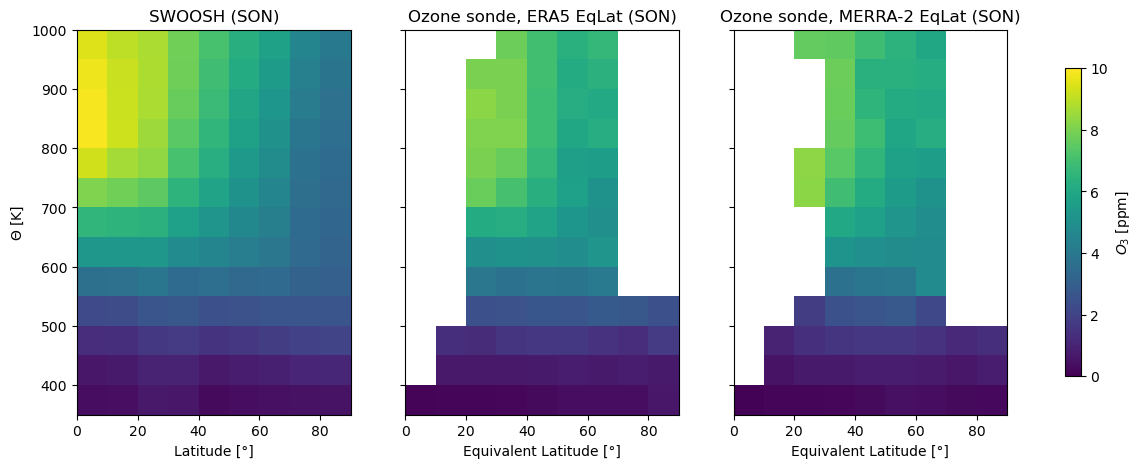

In [619]:
fig, axes = plot_swoosh_ozonesonde_comparison('SON')

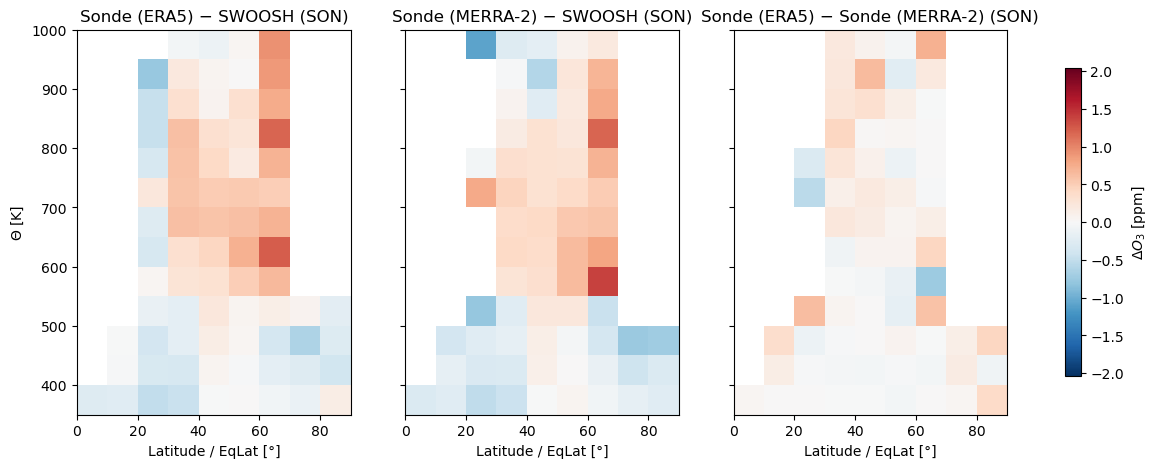

In [620]:
fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2) = plot_swoosh_ozonesonde_diff('SON')

In [611]:
def plot_ozonesonde_std_count(season):
    """Plot per-bin relative std and count for Ozone sonde O3 (ERA5 vs MERRA2 EqLat), NH only, one season.

    Relative std is std / mean (coefficient of variation), expressed as a percentage.
    Two rows (relative std, count) x two columns (ERA5, MERRA2), same style as
    plot_swoosh_ozonesonde_comparison.
    """
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = '$\\Theta$ [K]'

    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))

    era5_relstd = 100 * era5_nh['std'] / era5_nh['mean']
    merra2_relstd = 100 * merra2_nh['std'] / merra2_nh['mean']

    relstd_vmax = max(era5_relstd.max().item(), merra2_relstd.max().item())
    count_vmax = max(era5_nh['count'].max().item(), merra2_nh['count'].max().item())

    fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)

    era5_relstd.plot(ax=axes[0, 0], x='eqlat', y=vert_dim, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 0].set_title(f'$O_3$ sonde rel. std, ERA5 EqLat ({season})')
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel(ylabel)

    im_relstd = merra2_relstd.plot(ax=axes[0, 1], x='eqlat', y=vert_dim, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 1].set_title(f'$O_3$ sonde rel. std, MERRA-2 EqLat ({season})')
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylabel('')

    era5_nh['count'].where(era5_nh['count'] > 3).plot(ax=axes[1, 0], x='eqlat', y=vert_dim, vmin=0, vmax=count_vmax, add_colorbar=False)
    axes[1, 0].set_title(f'$O_3$ sonde count, ERA5 EqLat ({season})')
    axes[1, 0].set_xlabel('Equivalent Latitude [°]')
    axes[1, 0].set_ylabel(ylabel)

    im_count = merra2_nh['count'].where(merra2_nh['count'] > 3).plot(ax=axes[1, 1], x='eqlat', y=vert_dim, vmin=0, vmax=count_vmax, add_colorbar=False)
    axes[1, 1].set_title(f'$O_3$ sonde count, MERRA-2 EqLat ({season})')
    axes[1, 1].set_xlabel('Equivalent Latitude [°]')
    axes[1, 1].set_ylabel('')

    for ax in axes.flat:
        ax.set_ylim(350, 1000)

    fig.colorbar(im_relstd, ax=axes[0, :], label='relative std($O_3$) [%]', shrink=0.8)
    fig.colorbar(im_count, ax=axes[1, :], label='count', shrink=0.8)
    return fig, axes


# fig, axes = plot_ozonesonde_std_count('SON')

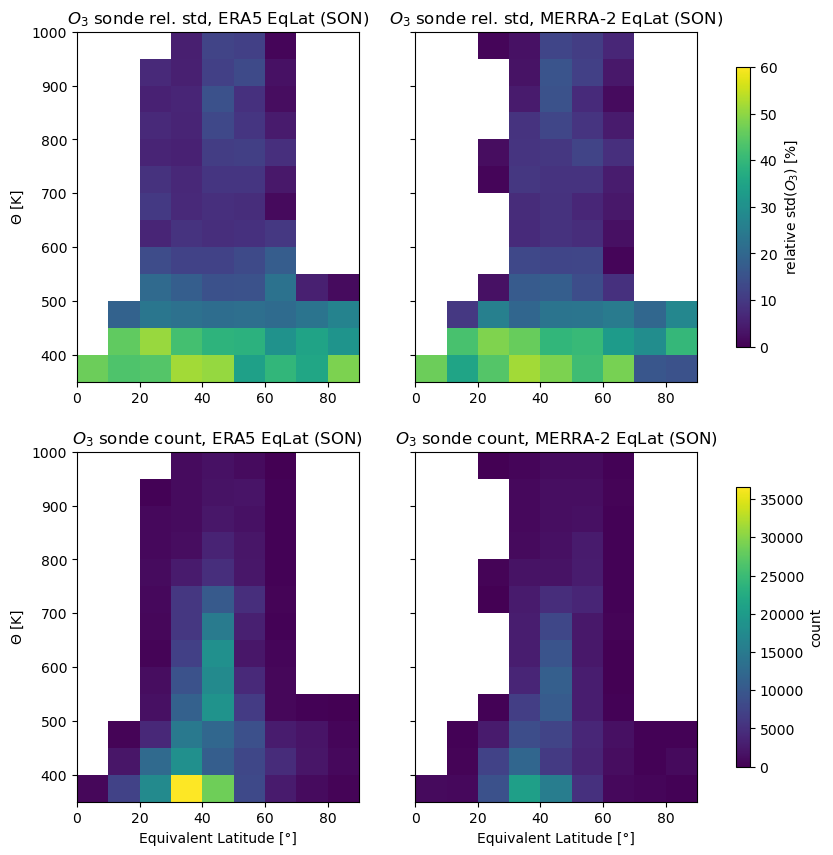

In [612]:
fig, axes = plot_ozonesonde_std_count('SON')